In [12]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# class SimpleGraphSAGE(nn.Module):
#     def __init__(self,input_dim,hidden_dim):
#         super(SimpleGraphSAGE,self).__init__()
#         self.linear_self=nn.Linear(input_dim,hidden_dim)
#         self.linear_neigh=nn.Linear(input_dim,hidden_dim)
#     def forward(self,x,adj):
#         neighbor_sum=torch.matmul(adj,x)
#         degree=adj.sum(dim=1,keepdim=True)+1e-6
#         neighbor_mean=neighbor_sum/degree
#         self_feature=self.linear_self(x)
#         neigh_feature=self.linear_neigh(neighbor_mean)
#         out=self_feature+neigh_feature
#         return F.relu(out)
# class MLPClassifier(nn.Module):
#     def __init__(self,input_dim):
#         super(MLPClassifier,self).__init__()
#         self.fc1=nn.Linear(input_dim,64)
#         self.fc2=nn.Linear(64,32)
#         self.fc3=nn.Linear(32,2)
#     def forward(self,x):
#         x=F.relu(self.fc1(x))
#         x=F.dropout(x,p=0.5,training=self.training)
#         x=F.relu(self.fc2(x))
#         x=F.dropout(x,p=0.5,training=self.training)
#         x=self.fc3(x)
#         return F.softmax(x,dim=1)
# class MLPRanker(nn.Module):
#     def __init__(self,input_dim):
#         super(MLPRanker,self).__init__()
#         self.fc1=nn.Linear(input_dim,64)
#         self.fc2=nn.Linear(64,32)
#         self.fc3=nn.Linear(32,1)
#     def forward(self,x):
#         x=F.relu(self.fc1(x))
#         x=F.dropout(x,p=0.5,training=self.training)
#         x=F.relu(self.fc2(x))
#         x=F.dropout(x,p=0.5,training=self.training)
#         x=self.fc3(x)
#         return x
# class BetweennessModel(nn.Module):
#     def __init__(self,node_feat_dim,hidden_dim):
#         super(BetweennessModel,self).__init__()
#         self.gnn1=SimpleGraphSAGE(node_feat_dim,hidden_dim)
#         self.gnn2=SimpleGraphSAGE(hidden_dim,hidden_dim)
#         self.classifier=MLPClassifier(hidden_dim*2)
#         self.ranker=MLPRanker(hidden_dim*2)
#     def forward(self,x,adj,edge_pairs):
#         h=self.gnn1(x,adj)
#         h=self.gnn2(h,adj)
#         u=edge_pairs[:,0]
#         v=edge_pairs[:,1]
#         edge_embeddings=torch.cat([h[u],h[v]],dim=1)
#         class_probs=self.classifier(edge_embeddings)
#         rank_scores=self.ranker(edge_embeddings)
#         return class_probs,rank_scores
# def classification_loss(pred_probs,labels):
#     return F.binary_cross_entropy(pred_probs[:,1],labels.float())
# def triplet_margin_loss(scores,triplets,margin=1.0):
#     loss=0
#     for t in triplets:
#         m,n,o=t
#         sm=scores[m]
#         sn=scores[n]
#         so=scores[o]
#         loss1=torch.maximum(torch.tensor(0.0),-(sm-sn)+margin)
#         loss2=torch.maximum(torch.tensor(0.0),-(sn-so)+margin)
#         loss3=torch.maximum(torch.tensor(0.0),-(so-sm)+margin)
#         loss+=loss1+loss2+loss3
#     return loss/len(triplets)
# num_nodes=100
# feature_dim=16
# x=torch.rand((num_nodes,feature_dim))
# adj=torch.randint(0,2,(num_nodes,num_nodes)).float()
# adj.fill_diagonal_(0)
# candidate_edges=torch.randint(0,num_nodes,(500,2))
# labels=torch.randint(0,2,(500,))
# triplets=torch.randint(0,500,(100,3))
# model=BetweennessModel(node_feat_dim=16,hidden_dim=32)
# optimizer=torch.optim.Adam(model.parameters(),lr=0.0085)
# model.train()
# for epoch in range(50):
#     optimizer.zero_grad()
#     class_probs,rank_scores=model(x,adj,candidate_edges)
#     loss_cls=classification_loss(class_probs,labels)
#     loss_rank=triplet_margin_loss(rank_scores.squeeze(),triplets)
#     total_loss=loss_cls+loss_rank
#     total_loss.backward()
#     optimizer.step()
#     print(f"Epoch {epoch+1}, Loss: {total_loss.item():.4f}")

Dataset: Cora()
Nodes: 2708
Edges: 10556
Features: 1433
Classes: 7
NetworkX Nodes: 2708
NetworkX Edges: 5278


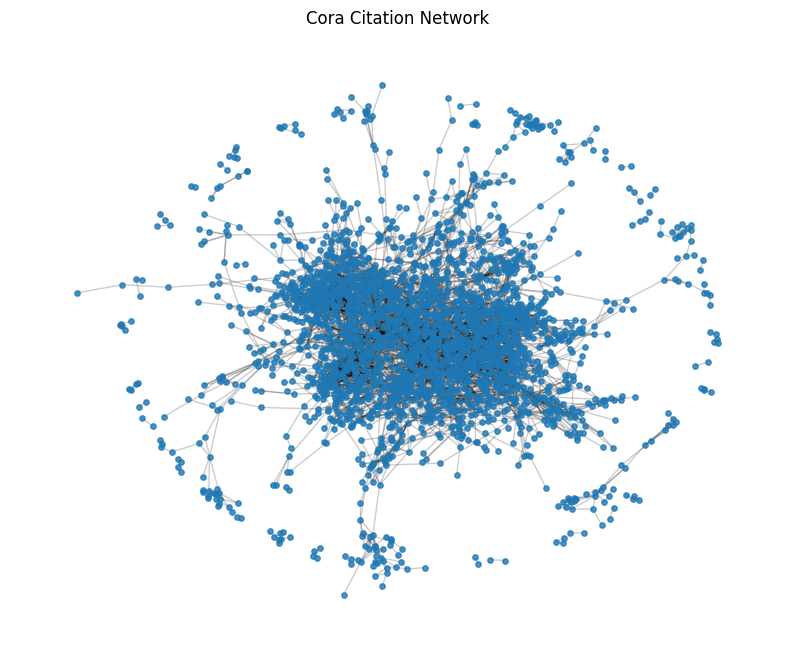

Computed Edge Betweenness for 5278 edges
Important Edges: 1055
Label Shape: torch.Size([5278])


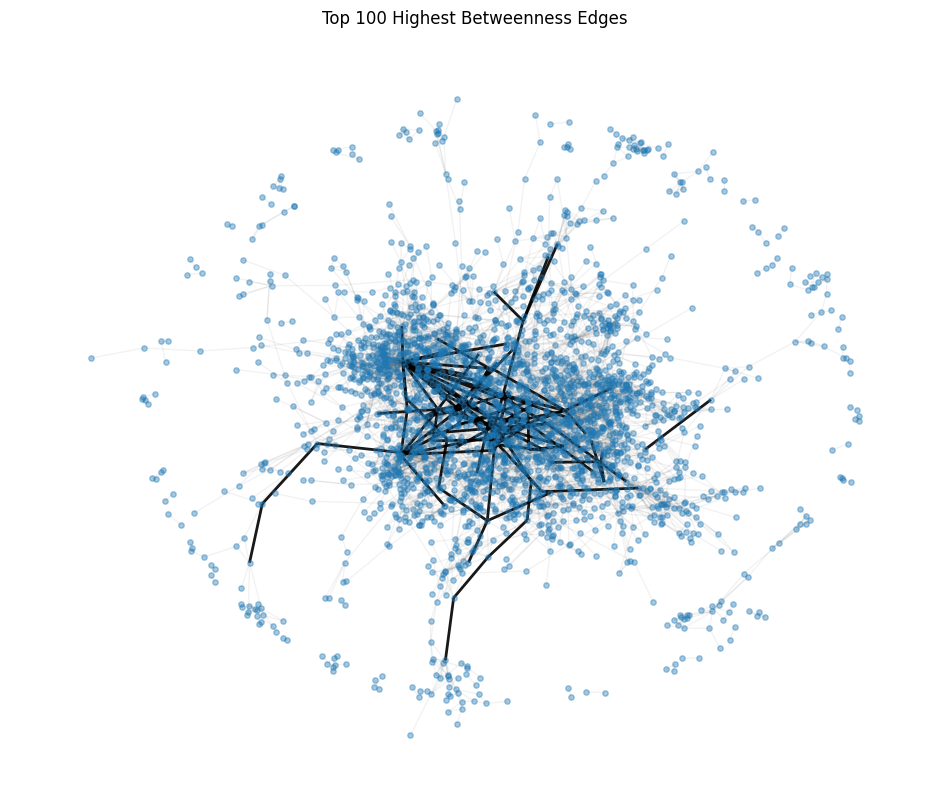

Candidate Edges Shape: torch.Size([5278, 2])
Triplets Shape: torch.Size([1000, 3])
Adjacency Shape: torch.Size([2708, 2708])
Node Feature Shape: torch.Size([2708, 1433])

Dataset Preparation Complete
Adjacency Matrix : torch.Size([2708, 2708])
Node Features    : torch.Size([2708, 1433])
Candidate Edges  : torch.Size([5278, 2])
Labels           : torch.Size([5278])
Triplets         : torch.Size([1000, 3])


In [10]:
!pip install torch_geometric
import torch
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.utils import to_networkx

dataset=Planetoid(root='data/Planetoid',name='Cora',transform=NormalizeFeatures())
data=dataset[0]

print("Dataset:",dataset)
print("Nodes:",data.num_nodes)
print("Edges:",data.num_edges)
print("Features:",dataset.num_features)
print("Classes:",dataset.num_classes)

G=to_networkx(data,to_undirected=True)

print("NetworkX Nodes:",G.number_of_nodes())
print("NetworkX Edges:",G.number_of_edges())

plt.figure(figsize=(10,8))
pos=nx.spring_layout(G,k=0.15,seed=42)

nx.draw_networkx_nodes(G,pos,node_size=15,alpha=0.8)
nx.draw_networkx_edges(G,pos,alpha=0.2)

plt.title("Cora Citation Network")
plt.axis("off")
plt.show()

edge_bc=nx.edge_betweenness_centrality(G)

print("Computed Edge Betweenness for",len(edge_bc),"edges")

sorted_edges=sorted(edge_bc.items(),key=lambda x:x[1],reverse=True)

threshold=int(0.2*len(sorted_edges))

important_edges=set([e for e,_ in sorted_edges[:threshold]])

print("Important Edges:",len(important_edges))

edge_list=list(G.edges())

labels=[]

for edge in edge_list:
    if edge in important_edges:
        labels.append(1)
    else:
        labels.append(0)

labels=torch.tensor(labels)

print("Label Shape:",labels.shape)

top_edges=[e for e,_ in sorted_edges[:100]]

plt.figure(figsize=(12,10))

nx.draw_networkx_nodes(G,pos,node_size=15,alpha=0.4)
nx.draw_networkx_edges(G,pos,alpha=0.05)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=top_edges,
    width=2,
    alpha=0.9
)

plt.title("Top 100 Highest Betweenness Edges")
plt.axis("off")
plt.show()

candidate_edges=torch.tensor(edge_list,dtype=torch.long)

print("Candidate Edges Shape:",candidate_edges.shape)

num_triplets=1000

triplets=[]

for _ in range(num_triplets):
    a=np.random.randint(len(edge_list))
    b=np.random.randint(len(edge_list))
    c=np.random.randint(len(edge_list))
    triplets.append([a,b,c])

triplets=torch.tensor(triplets)

print("Triplets Shape:",triplets.shape)

adj=torch.tensor(nx.to_numpy_array(G),dtype=torch.float)

print("Adjacency Shape:",adj.shape)
print("Node Feature Shape:",data.x.shape)

print("\nDataset Preparation Complete")
print("================================")
print("Adjacency Matrix :",adj.shape)
print("Node Features    :",data.x.shape)
print("Candidate Edges  :",candidate_edges.shape)
print("Labels           :",labels.shape)
print("Triplets         :",triplets.shape)

Epoch:000, Loss:2.7509, Acc:0.2001
Epoch:010, Loss:2.5613, Acc:0.8001
Epoch:020, Loss:2.5226, Acc:0.7997
Epoch:030, Loss:2.5050, Acc:0.8001
Epoch:040, Loss:2.4659, Acc:0.8001
Epoch:050, Loss:2.2782, Acc:0.8001
Epoch:060, Loss:1.9822, Acc:0.7994
Epoch:070, Loss:1.6880, Acc:0.8196
Epoch:080, Loss:1.4505, Acc:0.8369
Epoch:090, Loss:1.2431, Acc:0.8575

Final Results
Accuracy : 0.8863205759757484
Precision: 0.6881720430107527
Recall   : 0.7886255924170616
F1 Score : 0.734982332155477


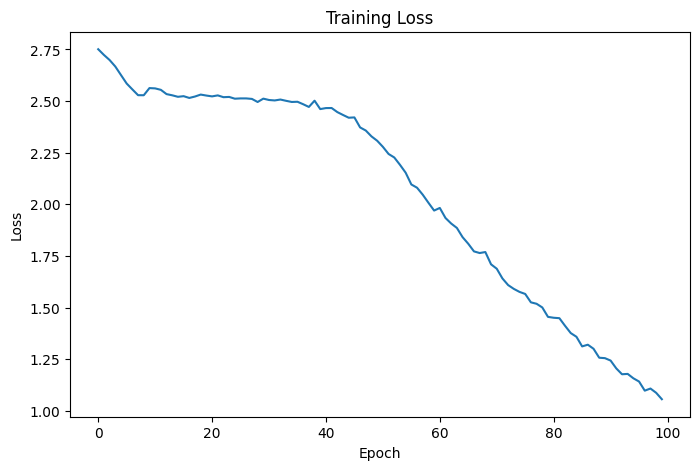

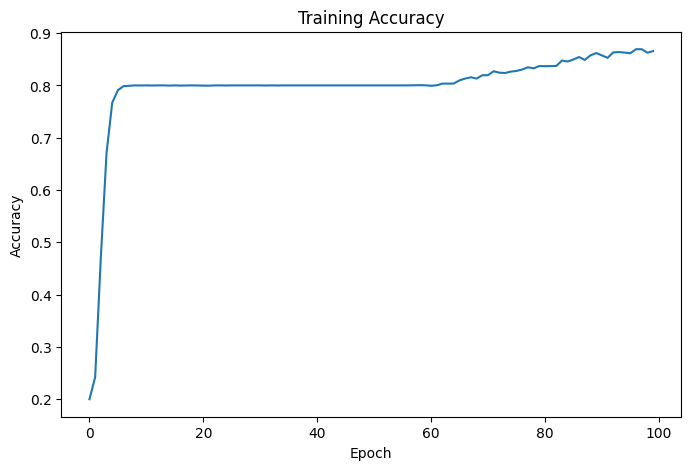

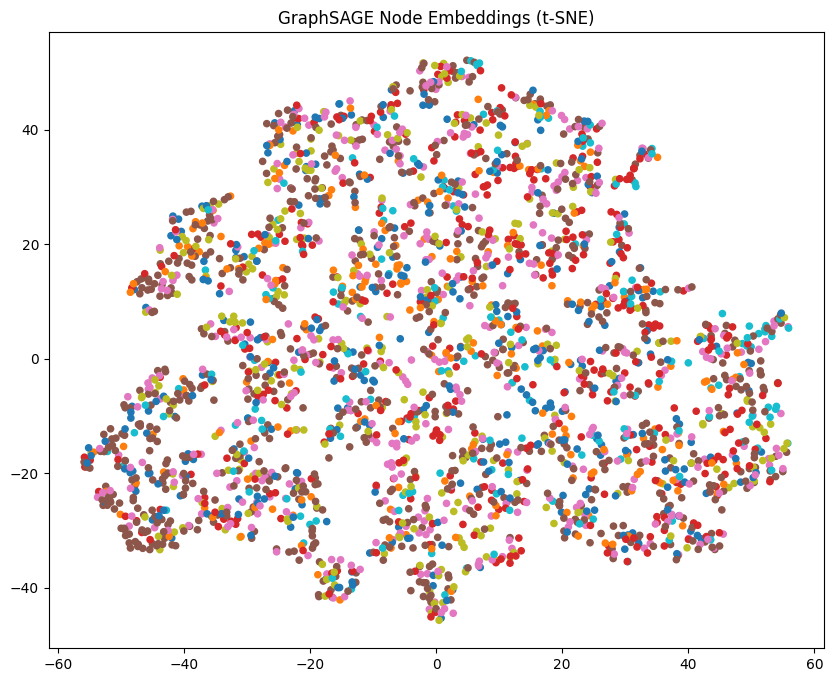

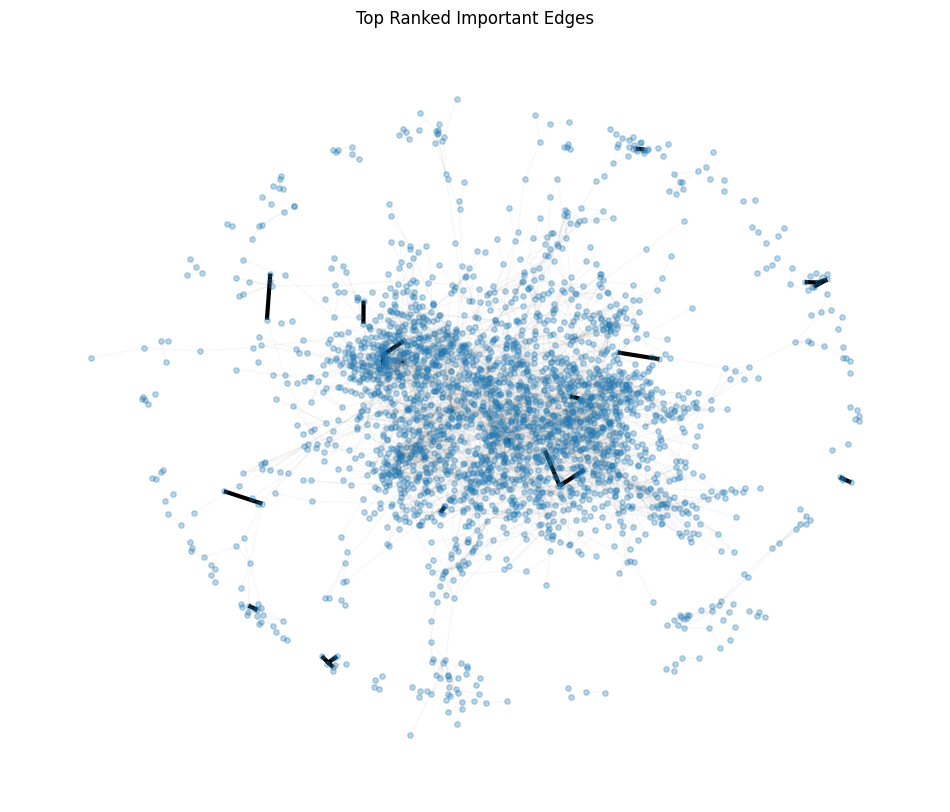


Top 20 Important Edges
(390, 1108) Score: 9.882537
(2483, 2484) Score: 7.8350363
(385, 2483) Score: 7.722092
(1290, 2258) Score: 6.6807976
(2146, 2148) Score: 6.588673
(785, 1664) Score: 6.434814
(84, 2223) Score: 6.178276
(91, 2123) Score: 6.173102
(66, 2631) Score: 6.1538377
(1751, 2596) Score: 6.0967183
(445, 909) Score: 6.0822387
(721, 1034) Score: 5.961634
(2022, 2190) Score: 5.8956094
(558, 1706) Score: 5.891414
(369, 385) Score: 5.8659062
(814, 1158) Score: 5.797524
(622, 1952) Score: 5.740888
(454, 2190) Score: 5.708915
(509, 2148) Score: 5.6985335
(1745, 2596) Score: 5.6487174


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.manifold import TSNE

class SimpleGraphSAGE(nn.Module):
    def __init__(self,input_dim,hidden_dim):
        super(SimpleGraphSAGE,self).__init__()
        self.linear_self=nn.Linear(input_dim,hidden_dim)
        self.linear_neigh=nn.Linear(input_dim,hidden_dim)

    def forward(self,x,adj):
        neighbor_sum=torch.matmul(adj,x)
        degree=adj.sum(dim=1,keepdim=True)+1e-6
        neighbor_mean=neighbor_sum/degree
        self_feature=self.linear_self(x)
        neigh_feature=self.linear_neigh(neighbor_mean)
        out=self_feature+neigh_feature
        return F.relu(out)

class MLPClassifier(nn.Module):
    def __init__(self,input_dim):
        super(MLPClassifier,self).__init__()
        self.fc1=nn.Linear(input_dim,64)
        self.fc2=nn.Linear(64,32)
        self.fc3=nn.Linear(32,2)

    def forward(self,x):
        x=F.relu(self.fc1(x))
        x=F.dropout(x,p=0.5,training=self.training)
        x=F.relu(self.fc2(x))
        x=F.dropout(x,p=0.5,training=self.training)
        x=self.fc3(x)
        return F.softmax(x,dim=1)

class MLPRanker(nn.Module):
    def __init__(self,input_dim):
        super(MLPRanker,self).__init__()
        self.fc1=nn.Linear(input_dim,64)
        self.fc2=nn.Linear(64,32)
        self.fc3=nn.Linear(32,1)

    def forward(self,x):
        x=F.relu(self.fc1(x))
        x=F.dropout(x,p=0.5,training=self.training)
        x=F.relu(self.fc2(x))
        x=F.dropout(x,p=0.5,training=self.training)
        x=self.fc3(x)
        return x

class BetweennessModel(nn.Module):
    def __init__(self,node_feat_dim,hidden_dim):
        super(BetweennessModel,self).__init__()
        self.gnn1=SimpleGraphSAGE(node_feat_dim,hidden_dim)
        self.gnn2=SimpleGraphSAGE(hidden_dim,hidden_dim)
        self.classifier=MLPClassifier(hidden_dim*2)
        self.ranker=MLPRanker(hidden_dim*2)

    def forward(self,x,adj,edge_pairs):
        h=self.gnn1(x,adj)
        h=self.gnn2(h,adj)

        u=edge_pairs[:,0]
        v=edge_pairs[:,1]

        edge_embeddings=torch.cat([h[u],h[v]],dim=1)

        class_probs=self.classifier(edge_embeddings)
        rank_scores=self.ranker(edge_embeddings)

        return class_probs,rank_scores,h

def classification_loss(pred_probs,labels):
    return F.binary_cross_entropy(pred_probs[:,1],labels.float())

def triplet_margin_loss(scores,triplets,margin=1.0):
    loss=0

    for t in triplets:
        m,n,o=t

        sm=scores[m]
        sn=scores[n]
        so=scores[o]

        loss1=torch.maximum(torch.tensor(0.0),-(sm-sn)+margin)
        loss2=torch.maximum(torch.tensor(0.0),-(sn-so)+margin)

        loss+=loss1+loss2

    return loss/len(triplets)

model=BetweennessModel(node_feat_dim=dataset.num_features,hidden_dim=32)

optimizer=torch.optim.Adam(model.parameters(),lr=0.005)

loss_history=[]
acc_history=[]

for epoch in range(100):

    model.train()

    optimizer.zero_grad()

    class_probs,rank_scores,h=model(data.x,adj,candidate_edges)

    loss_cls=classification_loss(class_probs,labels)

    loss_rank=triplet_margin_loss(rank_scores.squeeze(),triplets)

    total_loss=loss_cls+loss_rank

    total_loss.backward()

    optimizer.step()

    pred=(class_probs[:,1]>0.5).int()

    acc=accuracy_score(labels.numpy(),pred.detach().numpy())

    loss_history.append(total_loss.item())
    acc_history.append(acc)

    if epoch%10==0:
        print(f"Epoch:{epoch:03d}, Loss:{total_loss.item():.4f}, Acc:{acc:.4f}")

model.eval()

with torch.no_grad():
    class_probs,rank_scores,h=model(data.x,adj,candidate_edges)

pred=(class_probs[:,1]>0.5).int()

acc=accuracy_score(labels.numpy(),pred.detach().numpy())
prec=precision_score(labels.numpy(),pred.detach().numpy())
rec=recall_score(labels.numpy(),pred.detach().numpy())
f1=f1_score(labels.numpy(),pred.detach().numpy())

print("\nFinal Results")
print("======================")
print("Accuracy :",acc)
print("Precision:",prec)
print("Recall   :",rec)
print("F1 Score :",f1)

plt.figure(figsize=(8,5))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(acc_history)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.show()

embeddings=h.detach().numpy()

z=TSNE(n_components=2,random_state=42).fit_transform(embeddings)

plt.figure(figsize=(10,8))
plt.scatter(z[:,0],z[:,1],c=data.y,cmap="tab10",s=20)
plt.title("GraphSAGE Node Embeddings (t-SNE)")
plt.show()

top_k=20

scores=rank_scores.squeeze().detach().numpy()

top_indices=np.argsort(scores)[::-1][:top_k]

top_edges=[]

for idx in top_indices:
    edge=tuple(candidate_edges[idx].tolist())
    top_edges.append(edge)

plt.figure(figsize=(12,10))

nx.draw_networkx_nodes(G,pos,node_size=15,alpha=0.3)
nx.draw_networkx_edges(G,pos,alpha=0.03)

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=top_edges,
    width=3,
    alpha=1.0
)

plt.title("Top Ranked Important Edges")
plt.axis("off")
plt.show()

print("\nTop 20 Important Edges")
print("======================")

for idx in top_indices:
    edge=tuple(candidate_edges[idx].tolist())
    print(edge,"Score:",scores[idx])